<a href="https://colab.research.google.com/github/TunggTungg/AI_EXERCISEs/blob/main/BT_AI_CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Modules

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from keras.utils import np_utils
from sklearn.utils import shuffle
from keras.datasets import mnist, fashion_mnist, cifar100
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow as tf
import math as m
from keras.utils.np_utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

In [4]:
def plot_history(history_fine):
  f1 = history_fine.history['acc']
  val_f1 = history_fine.history['val_acc']

  loss = history_fine.history['loss']
  val_loss = history_fine.history['val_loss']

  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(f1, label='Acc')
  plt.plot(val_f1, label='Validation Acc')
  plt.legend(loc='lower right')
  plt.title('Accuracy')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Loss')
  plt.xlabel('epoch')
  plt.show()

def plot_reg_history(history_fine):
  loss = history_fine.history['loss']
  val_loss = history_fine.history['val_loss']
  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Loss')
  plt.xlabel('epoch')
  plt.show()

# 1.CIFAR100 (CNN)

## 1.1 Load Data

In [5]:
# Load Data
(x_train, y_train), (x_test, y_test) = cifar100.load_data()
x_pre = x_train[0]
y_pre = y_train[0]

# Preprocessing Data
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)

169017344/169001437 [==============================] - 4s 0us/step


## 1.2 Create Model

In [14]:
vgg_model = tf.keras.applications.VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(32,32,3),
)
vgg_model.trainable = False
model = tf.keras.Sequential()
model.add(vgg_model)
model.add(Flatten())
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(256, activation = 'relu'))
model.add(Dense(100, activation = 'softmax'))

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 1, 1, 512)         20024384  
                                                                 
 flatten_3 (Flatten)         (None, 512)               0         
                                                                 
 dense_12 (Dense)            (None, 1024)              525312    
                                                                 
 dense_13 (Dense)            (None, 1024)              1049600   
                                                                 
 dense_14 (Dense)            (None, 256)               262400    
                                                                 
 dense_15 (Dense)            (None, 100)               25700     
                                                                 
Total params: 21,887,396
Trainable params: 1,863,012
N

In [15]:
#reducing learning rate on plateau
rlrop = ReduceLROnPlateau(monitor='val_loss', mode='min', patience= 5, factor= 0.5, min_lr= 1e-6, verbose=1)

optimizer = tf.keras.optimizers.Adam(lr = 0.0001)
model.compile(optimizer= optimizer,
            loss='categorical_crossentropy',
            metrics=['acc'])

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


Epoch 1/10
391/391 [==============================] - 11s 28ms/step - loss: 2.0820 - acc: 0.4544 - val_loss: 2.5688 - val_acc: 0.3582 - lr: 1.0000e-04
Epoch 2/10
391/391 [==============================] - 11s 28ms/step - loss: 2.0541 - acc: 0.4613 - val_loss: 2.5744 - val_acc: 0.3538 - lr: 1.0000e-04
Epoch 3/10
391/391 [==============================] - 11s 28ms/step - loss: 2.0227 - acc: 0.4699 - val_loss: 2.5627 - val_acc: 0.3558 - lr: 1.0000e-04
Epoch 4/10
391/391 [==============================] - 11s 28ms/step - loss: 1.9949 - acc: 0.4775 - val_loss: 2.5649 - val_acc: 0.3571 - lr: 1.0000e-04
Epoch 5/10
391/391 [==============================] - 11s 28ms/step - loss: 1.9683 - acc: 0.4826 - val_loss: 2.5765 - val_acc: 0.3607 - lr: 1.0000e-04
Epoch 6/10
391/391 [==============================] - 11s 28ms/step - loss: 1.9401 - acc: 0.4869 - val_loss: 2.5703 - val_acc: 0.3581 - lr: 1.0000e-04
Epoch 7/10
391/391 [==============================] - 11s 28ms/step - loss: 1.9105 - acc: 0.49

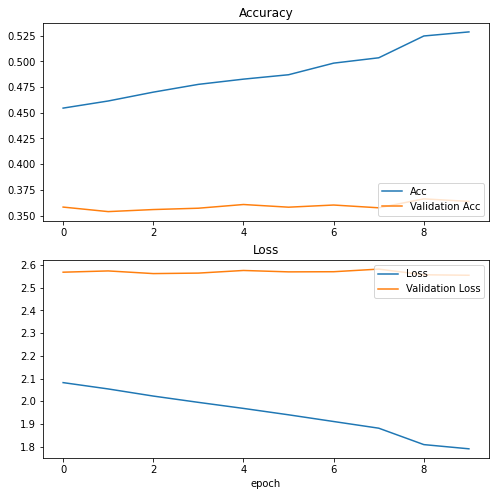

In [18]:
history = model.fit(
    x_train, y_train, batch_size = 128,
    validation_data =(x_test,y_test),
    epochs = 10,
    callbacks = [rlrop]
)
plot_history(history)

## 1.3 Predict

In [ ]:
cifar_100_Label = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

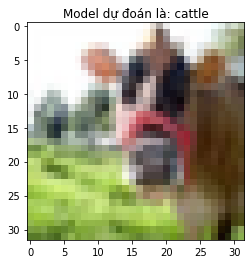

In [ ]:
plt.title("Model dự đoán là: " + str(cifar_100_Label[
                                 np.argmax(model.predict(x_pre.reshape((1,32,32,3))))]))
plt.imshow(x_pre, cmap=plt.get_cmap('gray'))

# 2.MNIST (CNN)

## 2.1 Load Data

In [ ]:
# Load Data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_pre = x_test[0]
y_pre = y_test[0]

# Preprocessing Data
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)

11501568/11490434 [==============================] - 0s 0us/step


## 1.2 Create Model

Epoch 1/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.1164 - acc: 0.9643 - val_loss: 0.0675 - val_acc: 0.9787
Epoch 2/15
1875/1875 [==============================] - 33s 18ms/step - loss: 0.0414 - acc: 0.9876 - val_loss: 0.0428 - val_acc: 0.9857
Epoch 3/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0296 - acc: 0.9909 - val_loss: 0.0419 - val_acc: 0.9880
Epoch 4/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0253 - acc: 0.9916 - val_loss: 0.0371 - val_acc: 0.9905
Epoch 5/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0203 - acc: 0.9937 - val_loss: 0.0302 - val_acc: 0.9914
Epoch 6/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0181 - acc: 0.9944 - val_loss: 0.0315 - val_acc: 0.9902
Epoch 7/15
1875/1875 [==============================] - 34s 18ms/step - loss: 0.0166 - acc: 0.9951 - val_loss: 0.0454 - val_acc: 0.9885
Epoch 8/15
1875/1875 [==========================

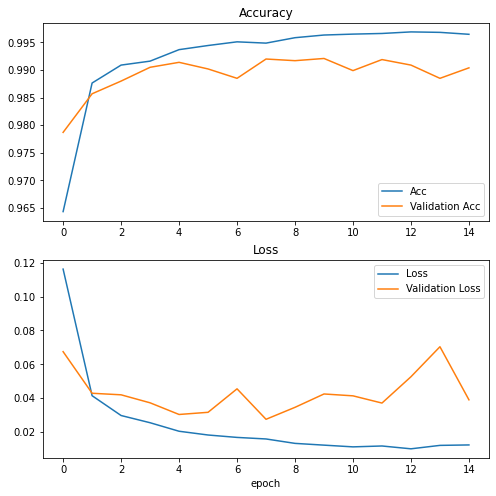

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 32, epochs = 15, validation_data =(x_test,y_test))

plot_history(history)

## 2.3 Predict

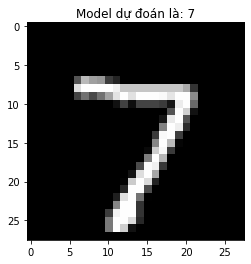

In [ ]:
plt.title("Model dự đoán là: " + str(np.argmax(model.predict(x_pre.reshape((1,28,28,1))))))
plt.imshow(x_pre, cmap=plt.get_cmap('gray'))

# 3.FASHION MNIST (CNN)

## 3.1 Load Data

In [ ]:
# Load Data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_pre = x_test[0]
y_pre = y_test[0]

# Preprocessing Data
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)

4431872/4422102 [==============================] - 0s 0us/step


## 3.2 Create Model

Epoch 1/5
1875/1875 [==============================] - 37s 19ms/step - loss: 0.3953 - acc: 0.8577 - val_loss: 0.2827 - val_acc: 0.8962
Epoch 2/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.2486 - acc: 0.9094 - val_loss: 0.2452 - val_acc: 0.9112
Epoch 3/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.2088 - acc: 0.9226 - val_loss: 0.2281 - val_acc: 0.9203
Epoch 4/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.1795 - acc: 0.9336 - val_loss: 0.2225 - val_acc: 0.9209
Epoch 5/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.1560 - acc: 0.9413 - val_loss: 0.2159 - val_acc: 0.9231


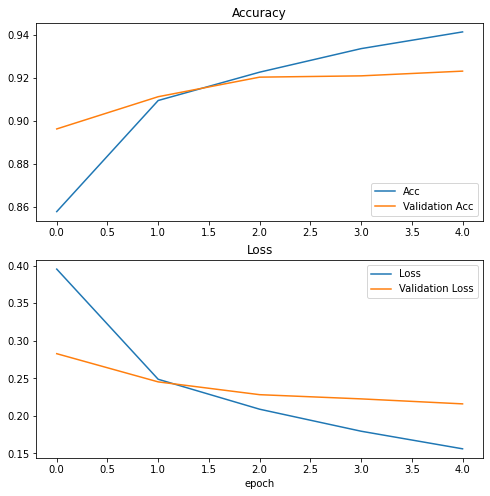

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 32, epochs = 5, validation_data =(x_test,y_test))

plot_history(history)

## 3.3 Predict

In [ ]:
Fashion_Mnist_Label = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

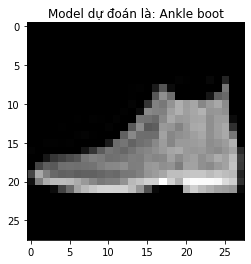

In [ ]:
plt.title("Model dự đoán là: " + str(Fashion_Mnist_Label[
                                                           np.argmax(model.predict(x_pre.reshape((1,28,28,1))))]))
plt.imshow(x_pre, cmap=plt.get_cmap('gray'))

# 4.Nhận Dạng Khuôn Mặt (CNN)

## 4.1 Load Data

In [ ]:
# Load Data 
with open('data.pickle', 'rb') as f:
    (x_train, y_train) = pickle.load(f)

# Reshape Data
x_pre_1 = x_train[101]
x_pre_2 = x_train[201]
x_pre_3 = x_train[301]


# Preprocessing Data
x_train = x_train.astype('float32')
x_train /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train, 4)

# Shuffe Data
x_train, y_train = shuffle(x_train, y_train)

## 4.2 Create Model

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (150,150,3)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(4, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 75, 75, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                    

In [ ]:
opt = Adam(lr = 0.001)
model.compile(optimizer = opt, loss = 'categorical_crossentropy', metrics = ['acc'])
his = model.fit(x_train, y_train, epochs = 15, batch_size = 64, validation_split = 0.2)

Epoch 1/15


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


5/5 [==============================] - 2s 215ms/step - loss: 2.0941 - acc: 0.8270 - val_loss: 0.2580 - val_acc: 0.8875
Epoch 2/15
5/5 [==============================] - 1s 136ms/step - loss: 0.0923 - acc: 0.9528 - val_loss: 0.0043 - val_acc: 1.0000
Epoch 3/15
5/5 [==============================] - 1s 137ms/step - loss: 0.0335 - acc: 0.9843 - val_loss: 2.4558e-04 - val_acc: 1.0000
Epoch 4/15
5/5 [==============================] - 1s 137ms/step - loss: 1.8502e-04 - acc: 1.0000 - val_loss: 9.8852e-06 - val_acc: 1.0000
Epoch 5/15
5/5 [==============================] - 1s 135ms/step - loss: 1.6760e-06 - acc: 1.0000 - val_loss: 2.1397e-06 - val_acc: 1.0000
Epoch 6/15
5/5 [==============================] - 1s 135ms/step - loss: 9.5803e-05 - acc: 1.0000 - val_loss: 3.9339e-07 - val_acc: 1.0000
Epoch 7/15
5/5 [==============================] - 1s 135ms/step - loss: 1.4770e-07 - acc: 1.0000 - val_loss: 1.4901e-09 - val_acc: 1.0000
Epoch 8/15
5/5 [==============================] - 1s 137ms/step -

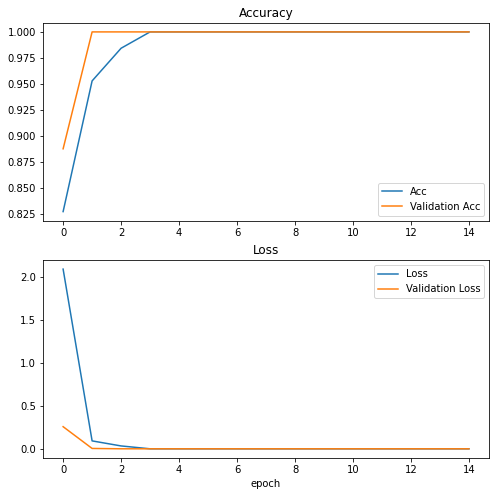

In [ ]:
plot_history(his)

## 4.3 Predict

In [ ]:
label = ['None', 'Tùng', 'Thành', 'Ninh']

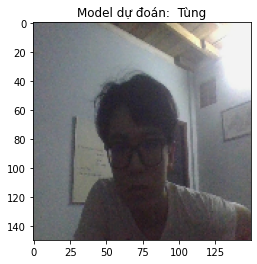

In [ ]:
plt.title("Model dự đoán:  " + label[np.argmax(model.predict(x_pre_1.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre_1, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

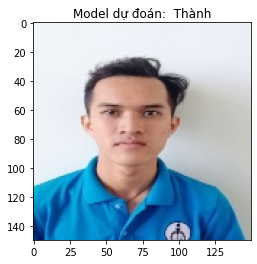

In [ ]:
plt.title("Model dự đoán:  " + label[np.argmax(model.predict(x_pre_2.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre_2, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

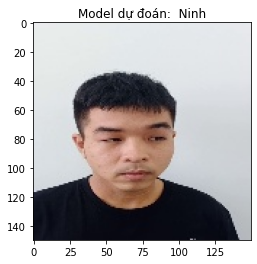

In [ ]:
plt.title("Model dự đoán:  " + label[np.argmax(model.predict(x_pre_3.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre_3, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

# 5.Món Ăn VN (CNN)

## 5.1 Load Data

In [ ]:
# Load Data 
with open('data_foods.pickle', 'rb') as f:
    (x_train, y_train) = pickle.load(f)

# Data for predict
x_pre = x_train[0]

# Preprocessing Data
x_train = x_train.astype('float32')
x_train /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train)

## 5.2 Create Model

Epoch 1/10
13/13 [==============================] - 39s 3s/step - loss: 46.6333 - acc: 0.2653 - val_loss: 34.6676 - val_acc: 0.0000e+00
Epoch 2/10
13/13 [==============================] - 0s 36ms/step - loss: 5.7961 - acc: 0.2857 - val_loss: 2.0542 - val_acc: 0.0000e+00
Epoch 3/10
13/13 [==============================] - 0s 30ms/step - loss: 1.0545 - acc: 0.6939 - val_loss: 5.0921 - val_acc: 0.0769
Epoch 4/10
13/13 [==============================] - 0s 28ms/step - loss: 0.3381 - acc: 0.9184 - val_loss: 7.9011 - val_acc: 0.0000e+00
Epoch 5/10
13/13 [==============================] - 0s 30ms/step - loss: 0.0347 - acc: 1.0000 - val_loss: 10.6333 - val_acc: 0.0769
Epoch 6/10
13/13 [==============================] - 0s 27ms/step - loss: 0.0022 - acc: 1.0000 - val_loss: 10.5087 - val_acc: 0.0769
Epoch 7/10
13/13 [==============================] - 0s 29ms/step - loss: 2.1224e-04 - acc: 1.0000 - val_loss: 10.5736 - val_acc: 0.0769
Epoch 8/10
13/13 [==============================] - 0s 27ms/ste

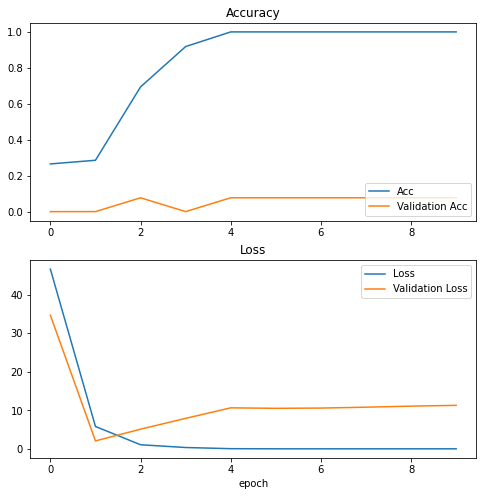

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (150,150,3)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(6, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 4, epochs = 10, validation_split=0.2)

plot_history(history)

## 5.3 Predict

In [ ]:
labels = ['bánh mì', 'bún đậu mắm tôm', 'canh chua', 'cơm chiên', 'hủ tiếu', 'phở']

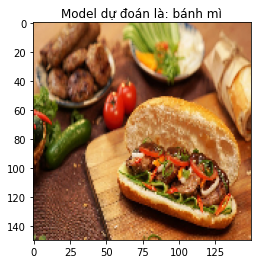

In [ ]:
plt.title("Model dự đoán là: " + labels[np.argmax(model.predict(x_pre.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

# 6.Tiền VN (CNN)

## 6.1 Load Data

In [ ]:
# Load Data 
with open('data_moneys.pickle', 'rb') as f:
    (x_train, y_train) = pickle.load(f)

# Data for predict
x_pre = x_train[20]

# Preprocessing Data
x_train = x_train.astype('float32')
x_train /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train)

## 6.2 Create Model

Epoch 1/10
9/9 [==============================] - 2s 113ms/step - loss: 60.5377 - acc: 0.1714 - val_loss: 26.6872 - val_acc: 0.0000e+00
Epoch 2/10
9/9 [==============================] - 0s 36ms/step - loss: 2.6915 - acc: 0.3714 - val_loss: 6.3659 - val_acc: 0.0000e+00
Epoch 3/10
9/9 [==============================] - 0s 33ms/step - loss: 0.9218 - acc: 0.7143 - val_loss: 3.9149 - val_acc: 0.1111
Epoch 4/10
9/9 [==============================] - 0s 37ms/step - loss: 0.3664 - acc: 0.9714 - val_loss: 7.2393 - val_acc: 0.1111
Epoch 5/10
9/9 [==============================] - 0s 36ms/step - loss: 0.1353 - acc: 0.9714 - val_loss: 8.5072 - val_acc: 0.1111
Epoch 6/10
9/9 [==============================] - 0s 30ms/step - loss: 0.0142 - acc: 1.0000 - val_loss: 11.2766 - val_acc: 0.1111
Epoch 7/10
9/9 [==============================] - 0s 28ms/step - loss: 0.0043 - acc: 1.0000 - val_loss: 11.5669 - val_acc: 0.1111
Epoch 8/10
9/9 [==============================] - 0s 31ms/step - loss: 0.0012 - acc:

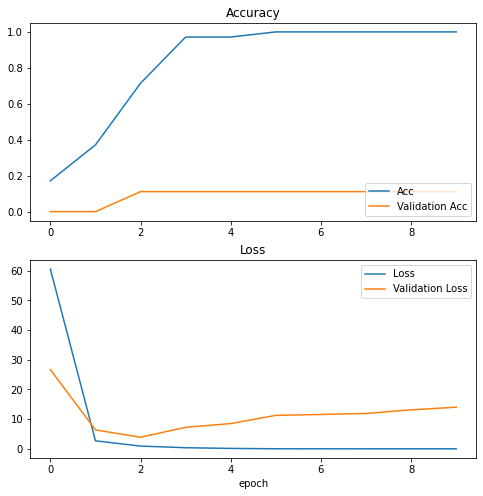

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (150,150,3)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(6, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 4, epochs = 10, validation_split=0.2)

plot_history(history)

## 6.3 Predict

In [ ]:
labels = ['1', '2', '5', '10', '20', '50', '100', '500']

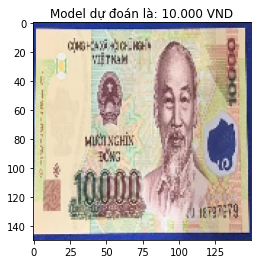

In [ ]:
plt.title("Model dự đoán là: " + labels[np.argmax(model.predict(x_pre.reshape(1,150,150,3)))] + '.000 VND')
plt.imshow(cv2.cvtColor(x_pre, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

# 7.Trái cây VN (CNN)

## 7.1 Load Data

In [ ]:
# Load Data 
with open('data_fruit.pickle', 'rb') as f:
    (x_train, y_train) = pickle.load(f)

# Data for predict
x_pre = x_train[17]

# Preprocessing Data
x_train = x_train.astype('float32')
x_train /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train)

## 7.2 Create Model

Epoch 1/10
14/14 [==============================] - 2s 65ms/step - loss: 36.1569 - acc: 0.3889 - val_loss: 33.3906 - val_acc: 0.0000e+00
Epoch 2/10
14/14 [==============================] - 0s 31ms/step - loss: 4.0343 - acc: 0.5741 - val_loss: 0.2900 - val_acc: 0.9286
Epoch 3/10
14/14 [==============================] - 0s 27ms/step - loss: 0.5481 - acc: 0.8889 - val_loss: 0.0285 - val_acc: 1.0000
Epoch 4/10
14/14 [==============================] - 0s 27ms/step - loss: 0.1435 - acc: 0.9259 - val_loss: 0.2322 - val_acc: 0.9286
Epoch 5/10
14/14 [==============================] - 0s 28ms/step - loss: 5.0767e-04 - acc: 1.0000 - val_loss: 0.7428 - val_acc: 0.8571
Epoch 6/10
14/14 [==============================] - 0s 27ms/step - loss: 0.0016 - acc: 1.0000 - val_loss: 0.6721 - val_acc: 0.8571
Epoch 7/10
14/14 [==============================] - 0s 27ms/step - loss: 3.7703e-04 - acc: 1.0000 - val_loss: 0.3273 - val_acc: 0.9286
Epoch 8/10
14/14 [==============================] - 0s 27ms/step - lo

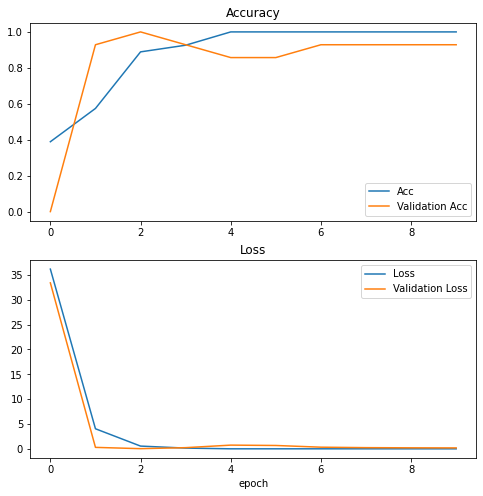

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (150,150,3)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 4, epochs = 10, validation_split=0.2)

plot_history(history)

## 7.3 Predict

In [ ]:
labels = ['bưởi', 'cam', 'cốc', 'khế', 'mít']

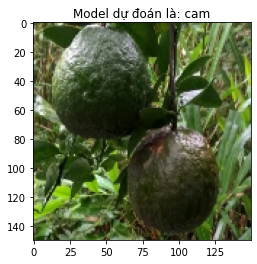

In [ ]:
plt.title("Model dự đoán là: " + labels[np.argmax(model.predict(x_pre.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))